# Anomaly Detection — Zone 1 / Zone 2 / Zone 3 Power Consumption

Three independent, leakage-safe detectors, tuned against a synthetic-injection
benchmark, plus a raw-vs-cleaned check that recovers extreme values the
preprocessing team's IQR capping suppressed (this matters a lot for Zone 3 —
its true maximum is ~28% higher than what the capped file shows).

| Signal | Catches |
|---|---|
| Isolation Forest | Multivariate context (value wrong for the weather/hour, even if not extreme alone) |
| Rolling z-score (mean/std) | Simple deviation from recent trend |
| Robust MAD z-score | Same idea, but resistant to being thrown off by the very spikes it's looking for |
| Raw-vs-cleaned capping check | Real extremes erased by upstream IQR capping (Zone 3 especially) |

All rolling windows are trailing (`shift(1)` before every `.rolling()`, never
`center=True`) so nothing here ever needs future data — it stays valid for
live/streaming scoring, not just retrospective batch analysis.

Running `python -m anomaly_detection.run_all` from the repo root does the same
thing end-to-end without a notebook.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent.parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
pd.set_option("display.width", 120)

from anomaly_detection.config import TARGETS, FIGURES_DIR, OUTPUT_DIR, PREDICTIONS_DIR, PUBLIC_RESULTS_DIR, TUNING_DIR, ensure_output_dirs
from anomaly_detection.data import load_feature_data, split_by_row
from anomaly_detection.evaluation import run_synthetic_benchmark, tune_all_thresholds
from anomaly_detection.pipeline import score_full_dataset
from anomaly_detection.visualization import plot_zone_anomalies, plot_severity_distribution

ensure_output_dirs()

## 1. Load data

In [2]:
df = load_feature_data()
splits = split_by_row(df)
print(df.shape)
{k: v.shape for k, v in splits.items()}

(52416, 53)


{'train': (36691, 53), 'validation': (7862, 53), 'test': (7863, 53)}

## 2. Tune every threshold against the synthetic-injection benchmark

No real anomaly labels exist for this dataset, so known spikes/dips are
injected into a copy of the test series and Precision/Recall/F1 are measured
against those injection points. Isolation Forest's contamination, the
z-score threshold, and the MAD threshold are each picked by which value
actually recovers the most injected anomalies — not by a proxy heuristic.

In [5]:
benchmark_frames = []
tuning_frames = []
best_params = {}

for zone, target in TARGETS.items():

    print()
    print("=" * 75)
    print(f"{zone}: {target}")
    print("=" * 75)

    # --------------------------------------------------------------
    # 1. Tune thresholds on TRAIN + VALIDATION
    # --------------------------------------------------------------

    best = tune_all_thresholds(
        train_df=splits["train"],
        validation_df=splits["validation"],
        zone=zone,
    )

    best_params[zone] = best
    tuning_frames.append(best["grid"])

    print()
    print("Selected parameters:")
    print(
        f"  Isolation Forest contamination = "
        f"{best['contamination']}"
    )
    print(
        f"  Statistical z-score threshold  = "
        f"{best['zscore_threshold']}"
    )
    print(
        f"  MAD z-score threshold          = "
        f"{best['mad_threshold']}"
    )

    # --------------------------------------------------------------
    # 2. Final benchmark on TEST
    # --------------------------------------------------------------

    bench = run_synthetic_benchmark(
        train_df=splits["train"],
        evaluation_df=splits["test"],
        zone=zone,
        contamination=best["contamination"],
        zscore_threshold=best["zscore_threshold"],
        mad_threshold=best["mad_threshold"],
    )

    benchmark_frames.append(bench)

    print()
    print("Benchmark results:")
    display(bench)


# ------------------------------------------------------------------
# Combine benchmark and tuning results
# ------------------------------------------------------------------

benchmark_df = pd.concat(
    benchmark_frames,
    ignore_index=True,
)

tuning_df = pd.concat(
    tuning_frames,
    ignore_index=True,
)


# ------------------------------------------------------------------
# Save benchmark results
# ------------------------------------------------------------------

benchmark_output = (
    PUBLIC_RESULTS_DIR
    / "results_anomaly_detection_benchmark.csv"
)

benchmark_df.to_csv(
    benchmark_output,
    index=False,
)


# ------------------------------------------------------------------
# Save tuning grid
# ------------------------------------------------------------------

tuning_output = (
    TUNING_DIR
    / "anomaly_detection_threshold_grid.csv"
)

tuning_df.to_csv(
    tuning_output,
    index=False,
)


# ------------------------------------------------------------------
# Print selected parameters
# ------------------------------------------------------------------

print()
print("=" * 75)
print("SELECTED PARAMETERS")
print("=" * 75)

for zone, best in best_params.items():

    print()
    print(zone)

    print(
        f"  contamination    : "
        f"{best['contamination']}"
    )

    print(
        f"  z-score threshold : "
        f"{best['zscore_threshold']}"
    )

    print(
        f"  MAD threshold     : "
        f"{best['mad_threshold']}"
    )


# ------------------------------------------------------------------
# Output paths
# ------------------------------------------------------------------

print()
print("=" * 75)
print("RESULTS SAVED")
print("=" * 75)

print()
print(f"Benchmark: {benchmark_output}")
print(f"Tuning   : {tuning_output}")

print()
print("Combined benchmark results:")
display(benchmark_df)


Zone_1: Zone_1_Power_Consumption

Selected parameters:
  Isolation Forest contamination = 0.02
  Statistical z-score threshold  = 4.0
  MAD z-score threshold          = 3.0

Benchmark results:


,Model,Zone,Precision,Recall,F1,Injected_Anomalies,Flagged,Notes
0,Isolation Forest,Zone_1,0.032680,0.160256,0.054289,156,765,Same production feature space; contamination=0...
1,Statistical Threshold,Zone_1,0.489583,0.903846,0.635135,156,288,|z| > 4.0; rolling 1h/24h mean/std; synthetic ...
2,Robust MAD Z-score,Zone_1,1.000000,0.596154,0.746988,156,93,|MAD z| > 3.0; trailing rolling MAD; synthetic...



Zone_2: Zone_2_Power_Consumption

Selected parameters:
  Isolation Forest contamination = 0.05
  Statistical z-score threshold  = 4.0
  MAD z-score threshold          = 3.0

Benchmark results:


,Model,Zone,Precision,Recall,F1,Injected_Anomalies,Flagged,Notes
0,Isolation Forest,Zone_2,0.024137,0.416667,0.045630,156,2693,Same production feature space; contamination=0...
1,Statistical Threshold,Zone_2,0.477816,0.897436,0.623608,156,293,|z| > 4.0; rolling 1h/24h mean/std; synthetic ...
2,Robust MAD Z-score,Zone_2,1.000000,0.455128,0.625551,156,71,|MAD z| > 3.0; trailing rolling MAD; synthetic...



Zone_3: Zone_3_Power_Consumption

Selected parameters:
  Isolation Forest contamination = 0.05
  Statistical z-score threshold  = 4.0
  MAD z-score threshold          = 5.0

Benchmark results:


,Model,Zone,Precision,Recall,F1,Injected_Anomalies,Flagged,Notes
0,Isolation Forest,Zone_3,0.026445,0.519231,0.050326,156,3063,Same production feature space; contamination=0...
1,Statistical Threshold,Zone_3,0.435737,0.891026,0.585263,156,319,|z| > 4.0; rolling 1h/24h mean/std; synthetic ...
2,Robust MAD Z-score,Zone_3,0.441667,0.679487,0.535354,156,240,|MAD z| > 5.0; trailing rolling MAD; synthetic...



SELECTED PARAMETERS

Zone_1
  contamination    : 0.02
  z-score threshold : 4.0
  MAD threshold     : 3.0

Zone_2
  contamination    : 0.05
  z-score threshold : 4.0
  MAD threshold     : 3.0

Zone_3
  contamination    : 0.05
  z-score threshold : 4.0
  MAD threshold     : 5.0

RESULTS SAVED

Benchmark: C:\Users\Dell\Documents\-Smart-Energy-Consumption-Prediction-System\anomaly_detection\docs\results\results_anomaly_detection_benchmark.csv
Tuning   : C:\Users\Dell\Documents\-Smart-Energy-Consumption-Prediction-System\anomaly_detection\internal_results\tuning\anomaly_detection_threshold_grid.csv

Combined benchmark results:


,Model,Zone,Precision,Recall,F1,Injected_Anomalies,Flagged,Notes
0,Isolation Forest,Zone_1,0.032680,0.160256,0.054289,156,765,Same production feature space; contamination=0...
1,Statistical Threshold,Zone_1,0.489583,0.903846,0.635135,156,288,|z| > 4.0; rolling 1h/24h mean/std; synthetic ...
2,Robust MAD Z-score,Zone_1,1.000000,0.596154,0.746988,156,93,|MAD z| > 3.0; trailing rolling MAD; synthetic...
3,Isolation Forest,Zone_2,0.024137,0.416667,0.045630,156,2693,Same production feature space; contamination=0...
4,Statistical Threshold,Zone_2,0.477816,0.897436,0.623608,156,293,|z| > 4.0; rolling 1h/24h mean/std; synthetic ...
5,Robust MAD Z-score,Zone_2,1.000000,0.455128,0.625551,156,71,|MAD z| > 3.0; trailing rolling MAD; synthetic...
6,Isolation Forest,Zone_3,0.026445,0.519231,0.050326,156,3063,Same production feature space; contamination=0...
7,Statistical Threshold,Zone_3,0.435737,0.891026,0.585263,156,319,|z| > 4.0; rolling 1h/24h mean/std; synthetic ...
8,Robust MAD Z-score,Zone_3,0.441667,0.679487,0.535354,156,240,|MAD z| > 5.0; trailing rolling MAD; synthetic...


## 3. Score the full dataset

Each zone's Isolation Forest is refit on the train split with its tuned contamination; the z-score and MAD thresholds are applied directly (no fitting needed — they're per-point transforms). The raw-vs-cleaned capping check runs automatically if `data/raw/` is present.

In [7]:
results = {}

for zone, target in TARGETS.items():

    print()
    print("=" * 75)
    print(f"Scoring {zone}: {target}")
    print("=" * 75)

    best = best_params[zone]

    result = score_full_dataset(
        df=df,
        zone=zone,
        zscore_threshold=best["zscore_threshold"],
        mad_threshold=best["mad_threshold"],
        contamination=best["contamination"],
    )

    results[zone] = result

    # --------------------------------------------------------------
    # Save per-zone result
    # --------------------------------------------------------------

    zone_output = (
        OUTPUT_DIR
        / f"anomalies_{zone.lower()}.csv"
    )

    result.to_csv(
        zone_output,
        index=False,
    )

    print(f"Saved: {zone_output}")

    # --------------------------------------------------------------
    # Generate plots
    # --------------------------------------------------------------

    plot_zone_anomalies(
        result,
        target,
    )

    plot_severity_distribution(
        result,
        target,
    )

    # --------------------------------------------------------------
    # Zone summary
    # --------------------------------------------------------------

    n_flagged = int(
        result["Is_Anomaly"].sum()
    )

    n_eligible = int(
        result["Eligible_For_Scoring"].sum()
    )

    n_critical = int(
        (
            result["Severity_Level"]
            == "Critical"
        ).sum()
    )

    # Current pipeline column name
    n_changed = int(
        result["Changed_By_Preprocessing"].sum()
    )

    flagged_percentage = (
        n_flagged / n_eligible
        if n_eligible > 0
        else 0.0
    )

    print()
    print("Zone summary:")
    print(
        f"  Flagged anomalies     : "
        f"{n_flagged:,}"
    )
    print(
        f"  Eligible rows         : "
        f"{n_eligible:,}"
    )
    print(
        f"  Flagged percentage    : "
        f"{flagged_percentage:.2%}"
    )
    print(
        f"  Critical observations : "
        f"{n_critical:,}"
    )
    print(
        f"  Preprocessing changed : "
        f"{n_changed:,}"
    )


# ------------------------------------------------------------------
# Combine all zones
# ------------------------------------------------------------------

combined = pd.concat(
    results.values(),
    ignore_index=True,
)


# ------------------------------------------------------------------
# Save combined dashboard output
# ------------------------------------------------------------------

combined_output = (
    OUTPUT_DIR
    / "anomalies_all_zones.csv"
)

combined.to_csv(
    combined_output,
    index=False,
)


# ------------------------------------------------------------------
# Save internal prediction output
# ------------------------------------------------------------------

predictions_output = (
    PREDICTIONS_DIR
    / "predictions_anomaly_detection.csv"
)

combined.to_csv(
    predictions_output,
    index=False,
)


# ------------------------------------------------------------------
# Final summary
# ------------------------------------------------------------------

print()
print("=" * 75)
print("FULL DATASET SCORING COMPLETE")
print("=" * 75)

print()
print(f"Combined output:")
print(f"  {combined_output}")

print()
print(f"Internal predictions:")
print(f"  {predictions_output}")

print()
print("Rows by zone:")

for zone, result in results.items():
    print(
        f"  {zone}: "
        f"{len(result):,} rows"
    )

print()
print(
    f"Total combined rows: "
    f"{len(combined):,}"
)


Scoring Zone_1: Zone_1_Power_Consumption
Saved: C:\Users\Dell\Documents\-Smart-Energy-Consumption-Prediction-System\anomaly_detection\outputs\anomalies_zone_1.csv

Zone summary:
  Flagged anomalies     : 2,212
  Eligible rows         : 52,272
  Flagged percentage    : 4.23%
  Critical observations : 142
  Preprocessing changed : 0

Scoring Zone_2: Zone_2_Power_Consumption
Saved: C:\Users\Dell\Documents\-Smart-Energy-Consumption-Prediction-System\anomaly_detection\outputs\anomalies_zone_2.csv

Zone summary:
  Flagged anomalies     : 5,559
  Eligible rows         : 52,272
  Flagged percentage    : 10.63%
  Critical observations : 440
  Preprocessing changed : 7

Scoring Zone_3: Zone_3_Power_Consumption
Saved: C:\Users\Dell\Documents\-Smart-Energy-Consumption-Prediction-System\anomaly_detection\outputs\anomalies_zone_3.csv

Zone summary:
  Flagged anomalies     : 7,581
  Eligible rows         : 52,272
  Flagged percentage    : 14.50%
  Critical observations : 1,817
  Preprocessing change

## 4. Zone 3's recovered spike

A concrete check: the single largest real Zone 3 spike (2017-07-24 20:10, 47,598 W) was capped down to 34,366 W by preprocessing's IQR treatment. It should show up here as `Capped_By_Preprocessing=True` and `Severity_Level='Critical'`.

In [8]:
z3 = results["Zone_3"]

z3[
    z3["DateTime"] == "2017-07-24 20:10:00"
][
    [
        "DateTime",
        "Value_Watts",
        "Raw_Value_Watts",
        "Changed_By_Preprocessing",
        "Suppressed_Amount_Watts",
        "Severity_Level",
        "Is_Anomaly",
    ]
]

,DateTime,Value_Watts,Raw_Value_Watts,Changed_By_Preprocessing,Suppressed_Amount_Watts,Severity_Level,Is_Anomaly
29497,2017-07-24 20:10:00,34366.261105,47598.32636,True,13232.065255,Critical,True


## 5. Visual check


Zone_1


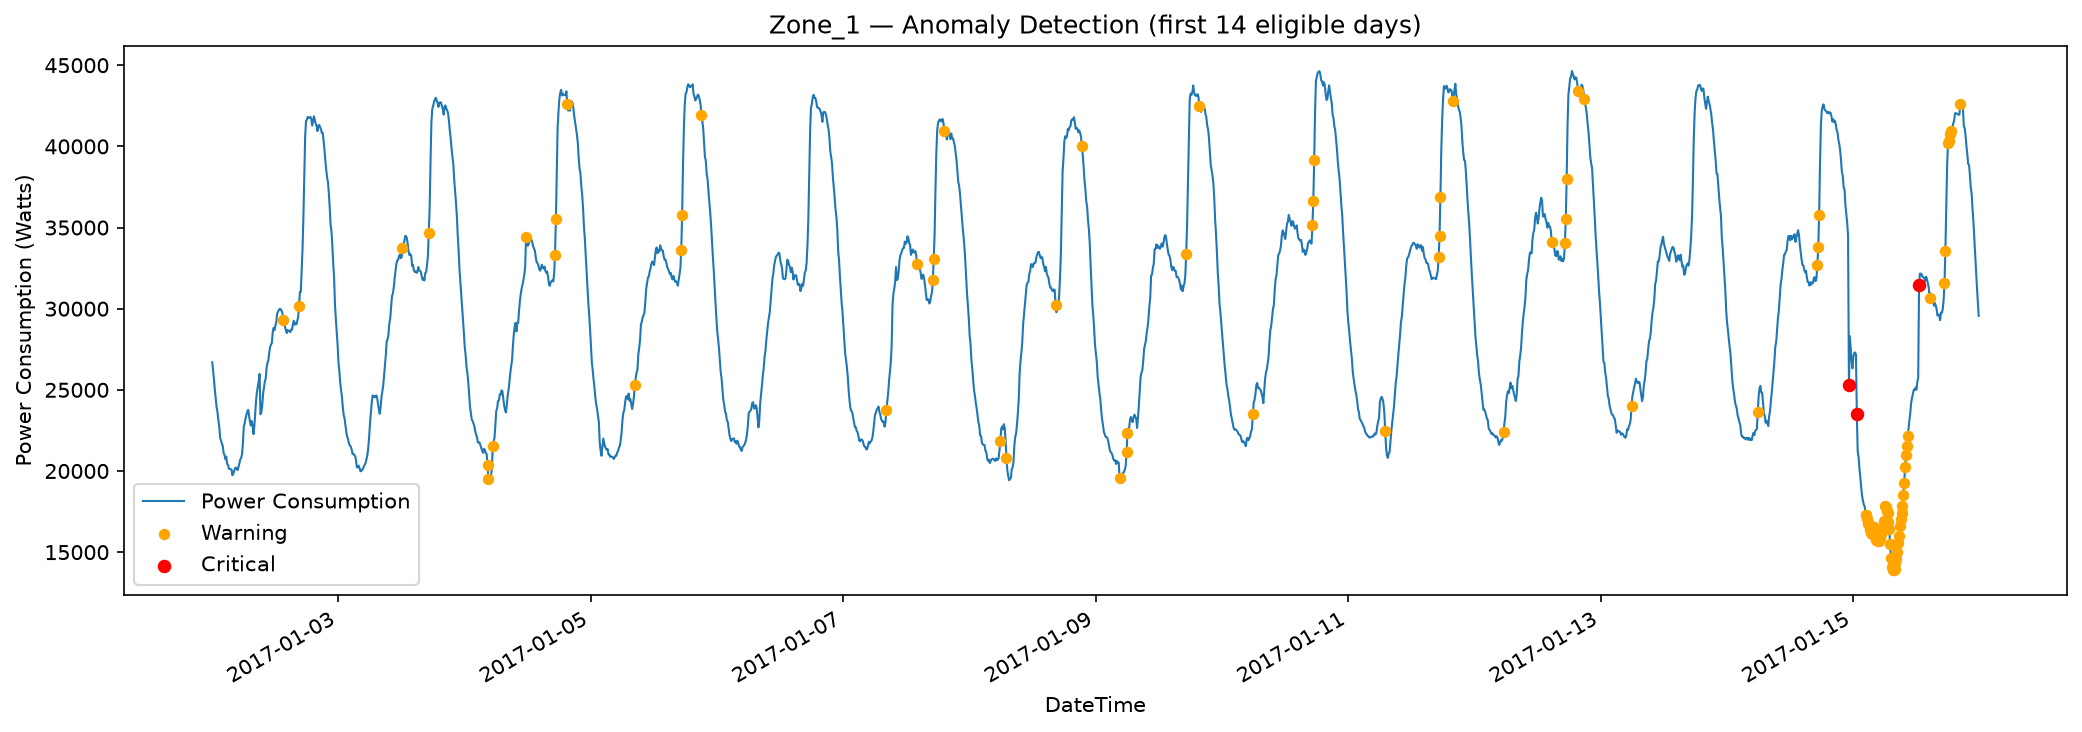

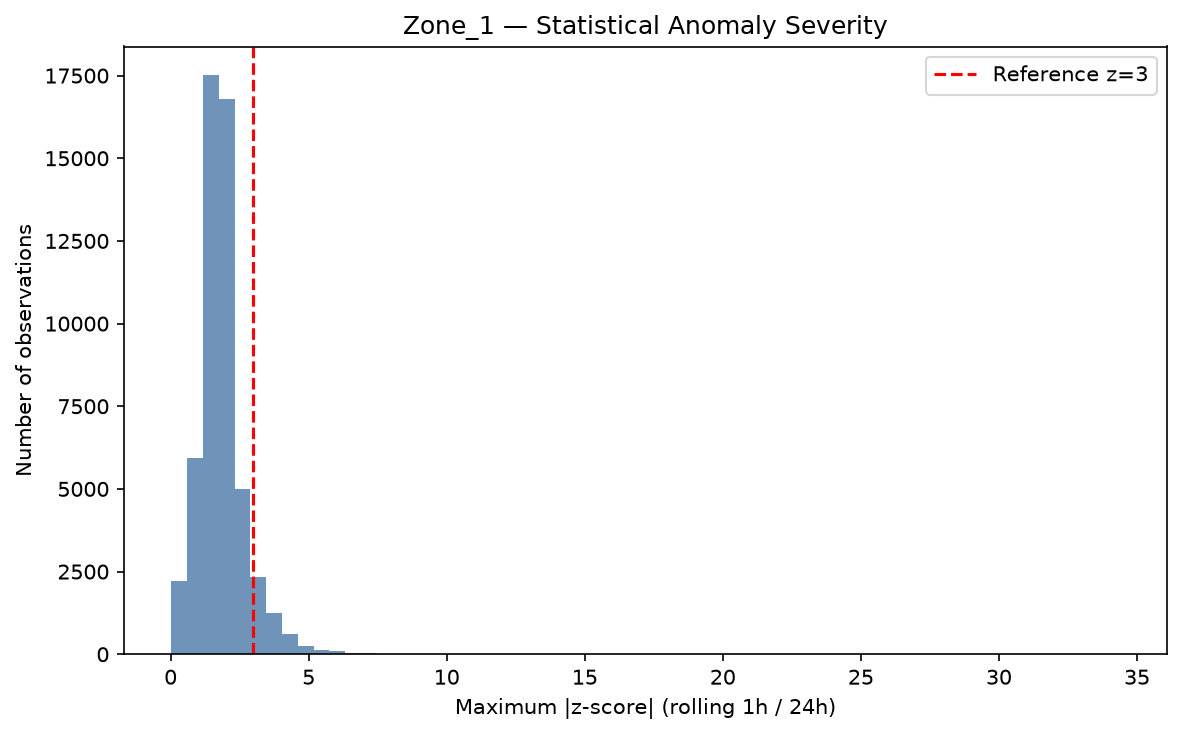


Zone_2


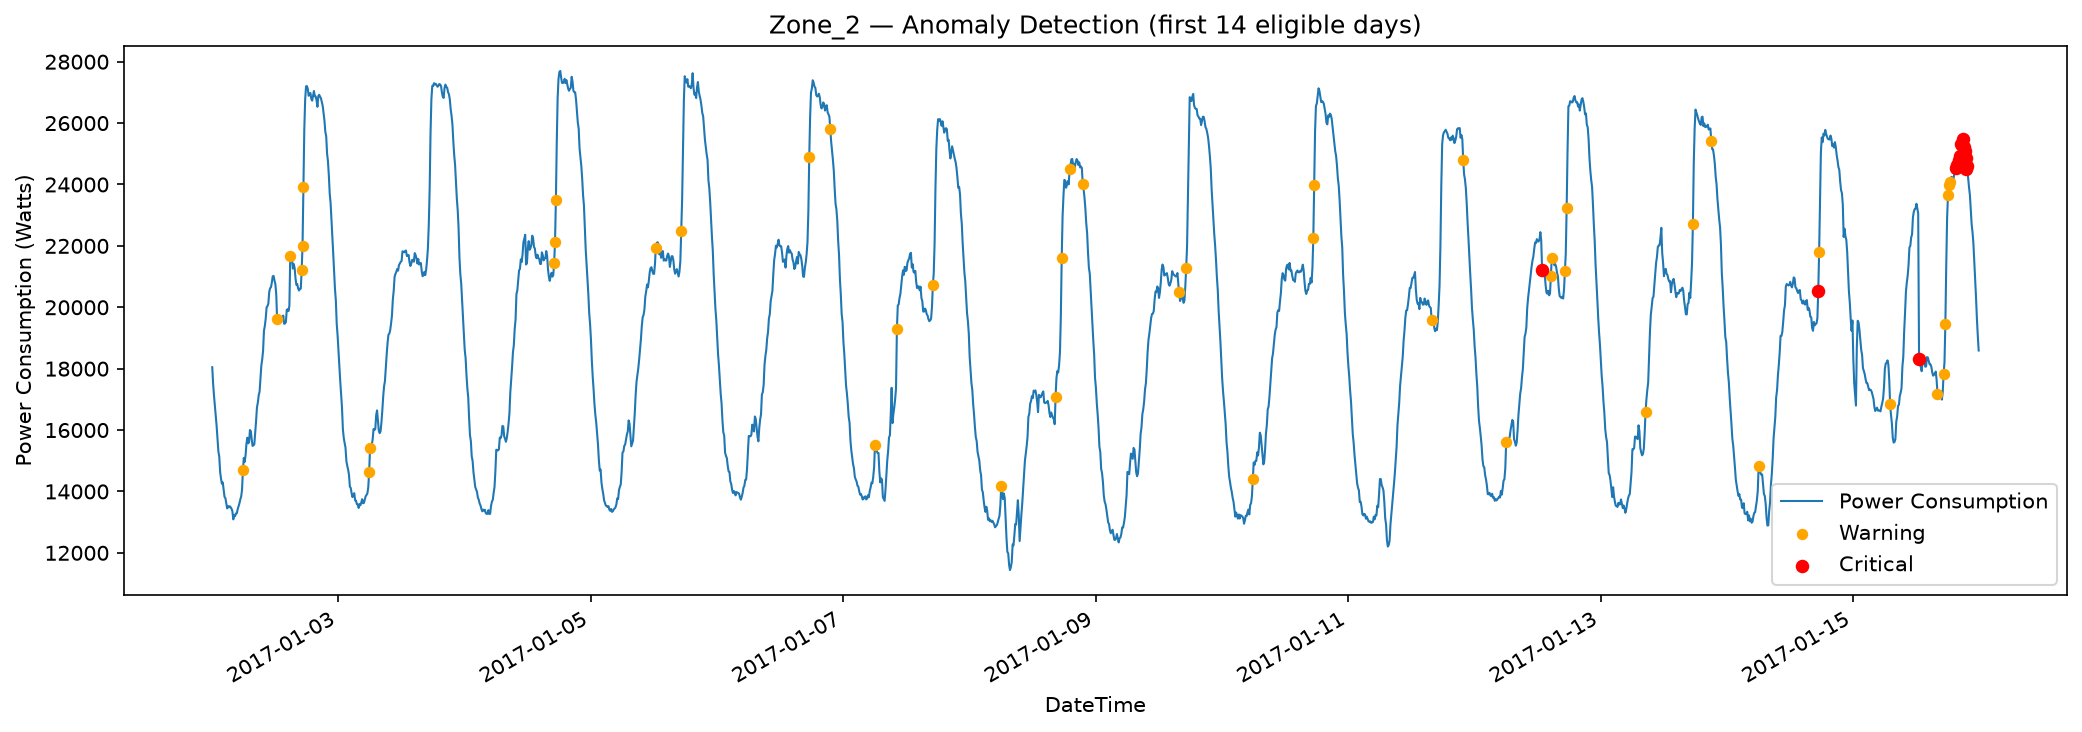

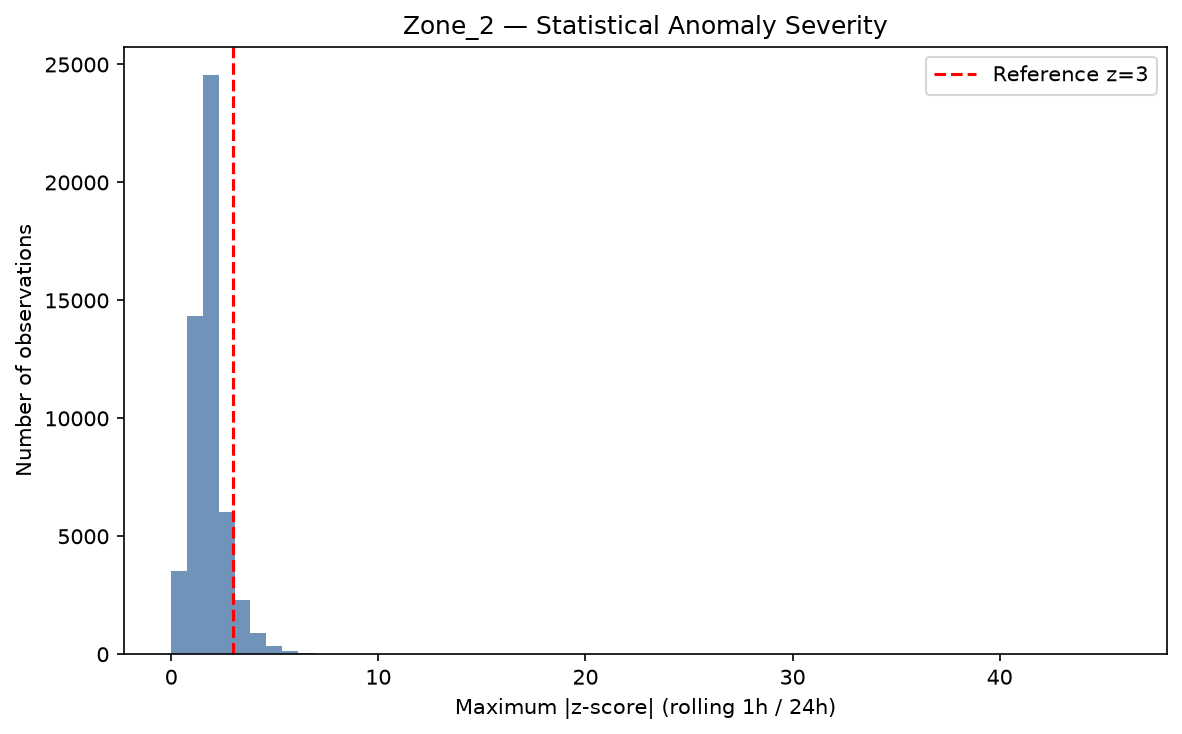


Zone_3


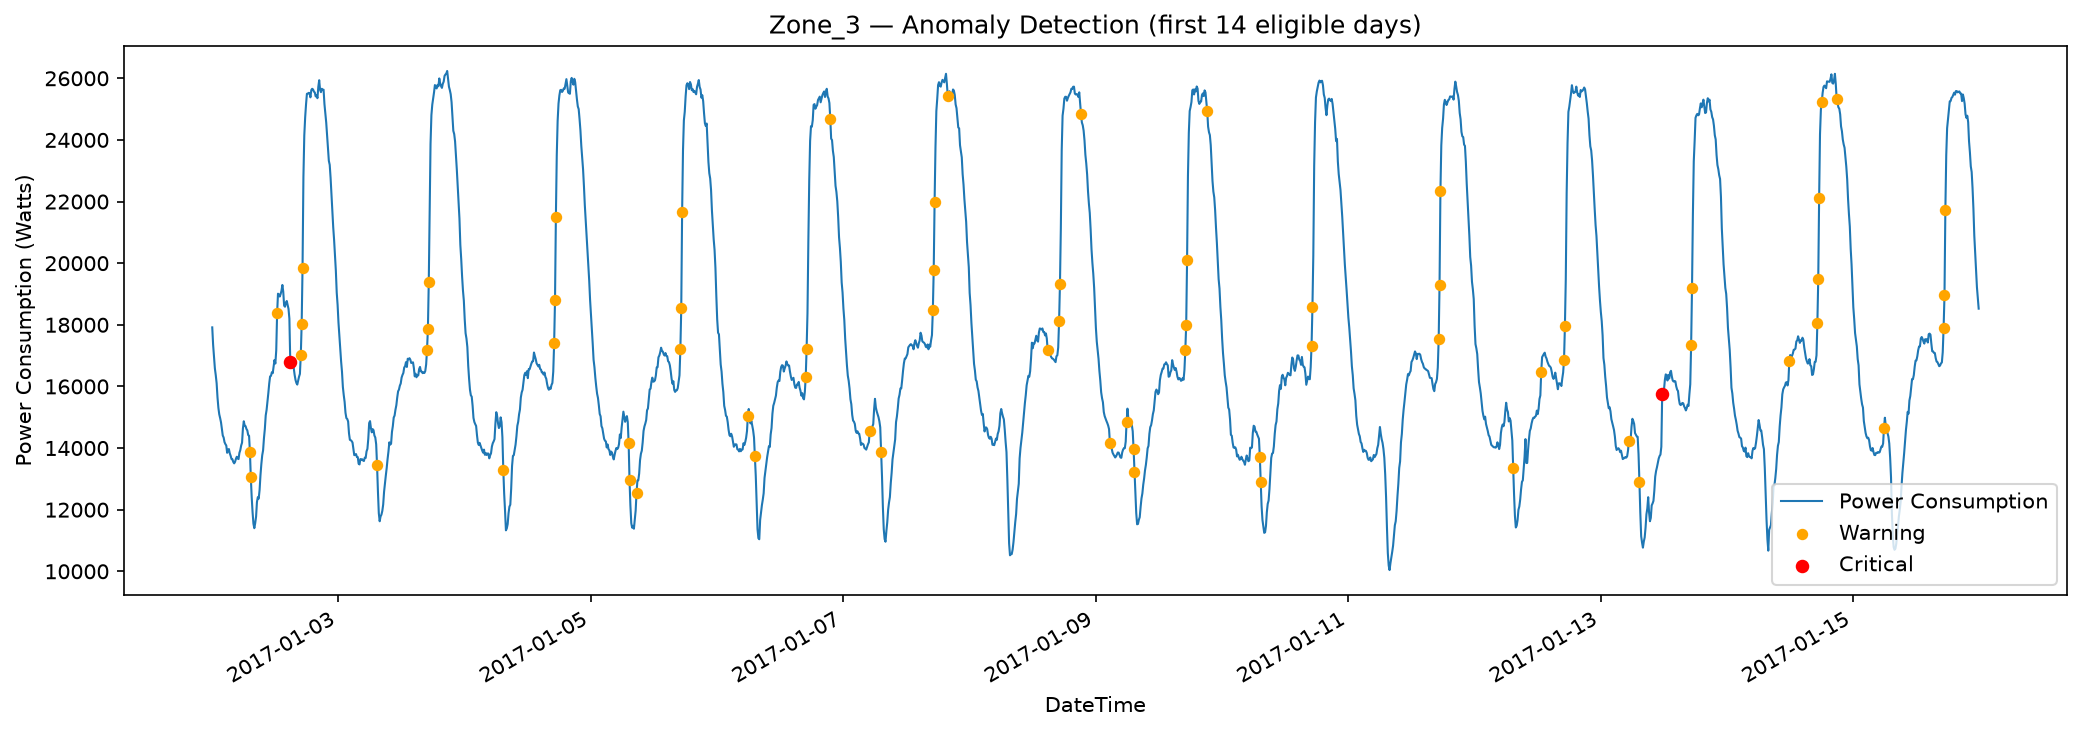

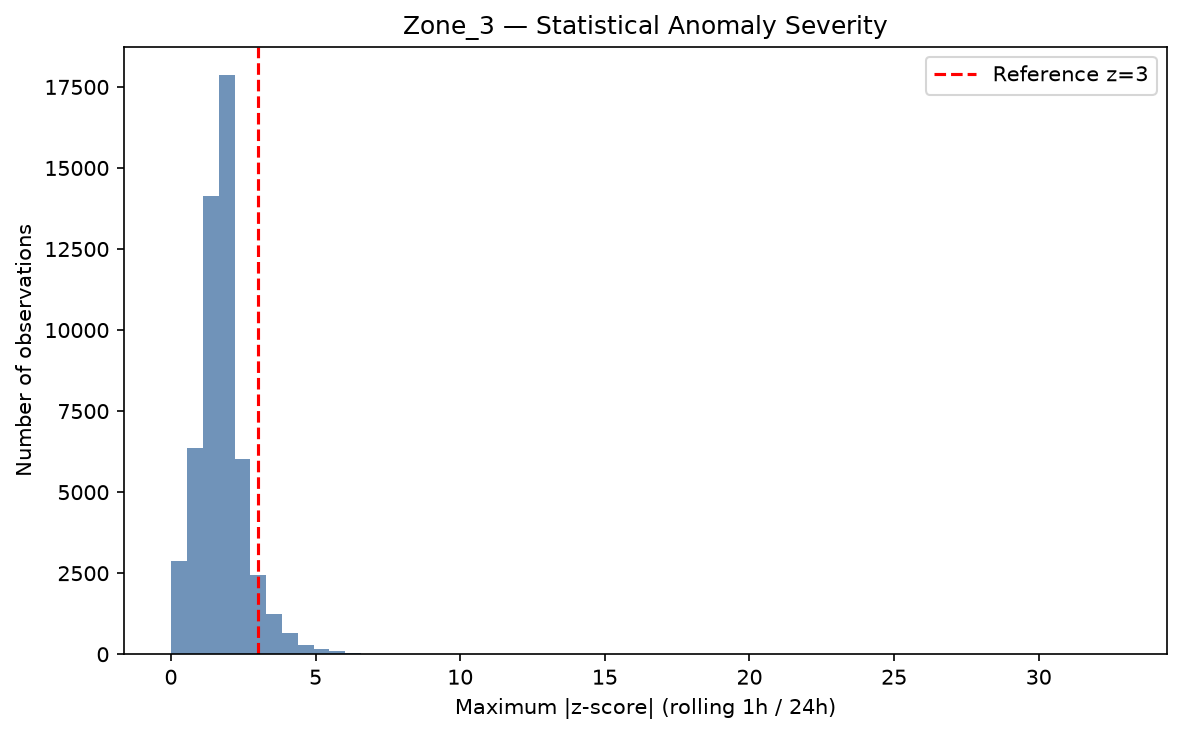

In [9]:
from IPython.display import Image, display

for zone in TARGETS:
    print(f"\n{zone}")

    display(
        Image(
            filename=str(
                FIGURES_DIR
                / f"anomalies_{zone.lower()}.png"
            )
        )
    )

    display(
        Image(
            filename=str(
                FIGURES_DIR
                / f"severity_distribution_{zone.lower()}.png"
            )
        )
    )

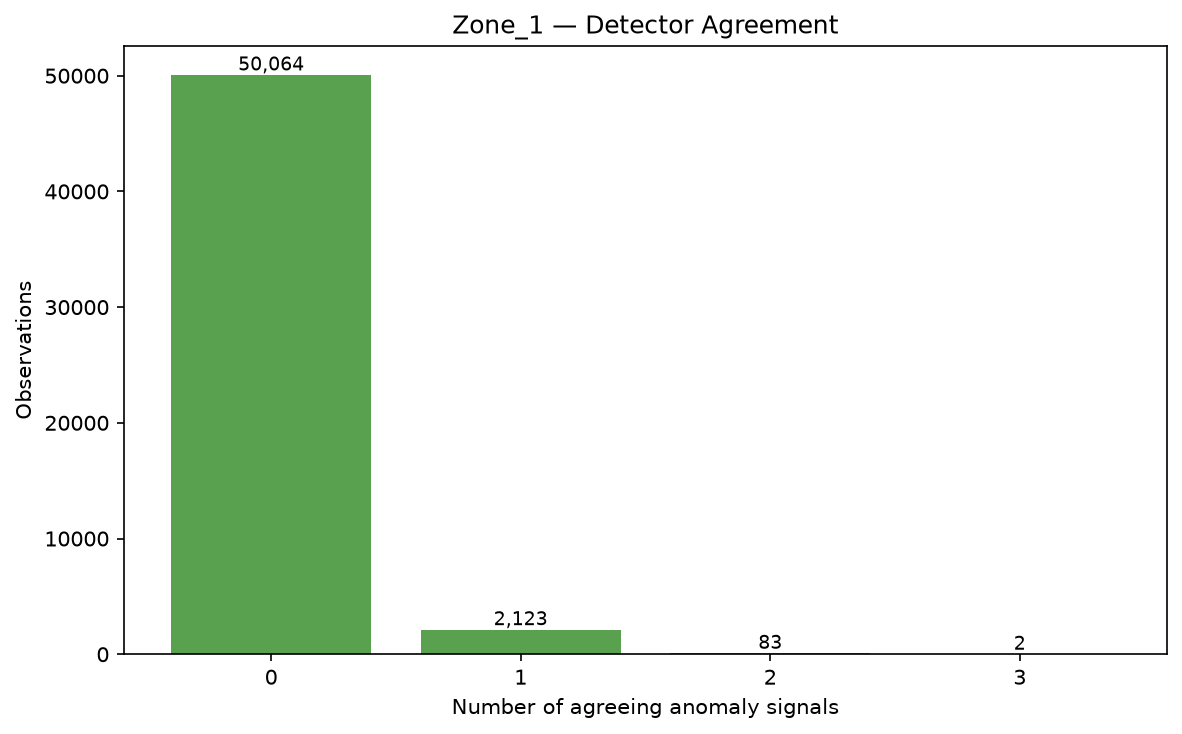

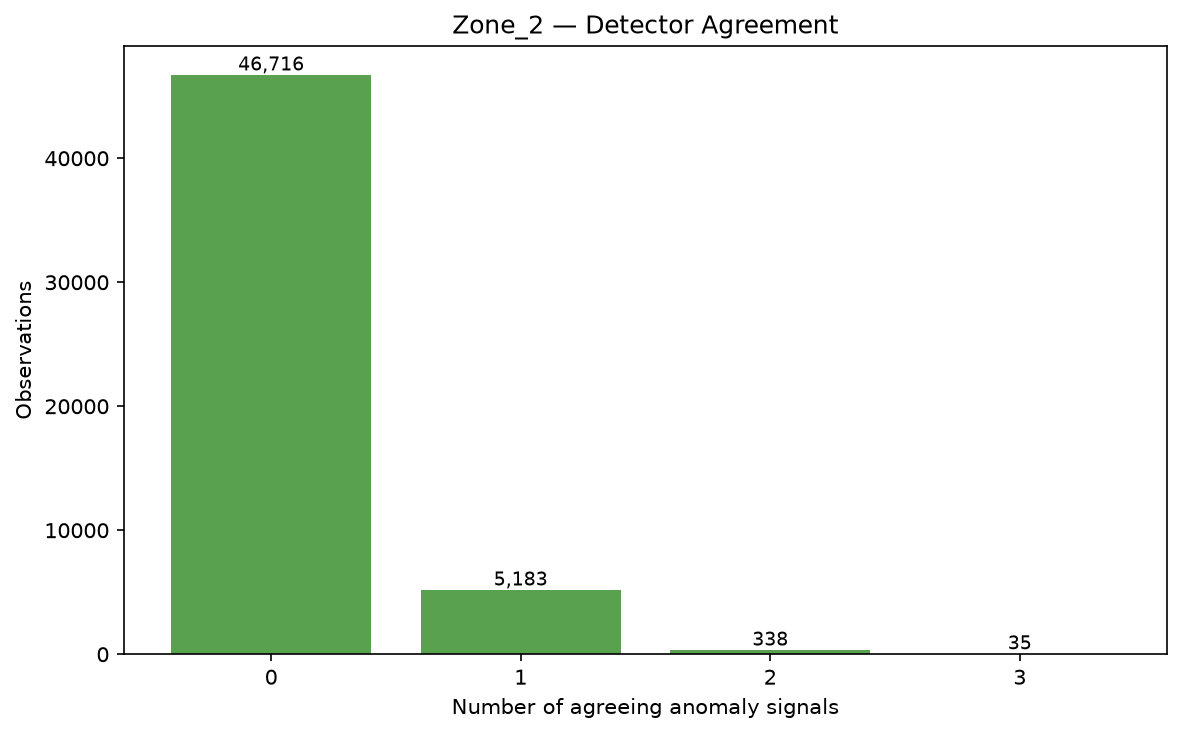

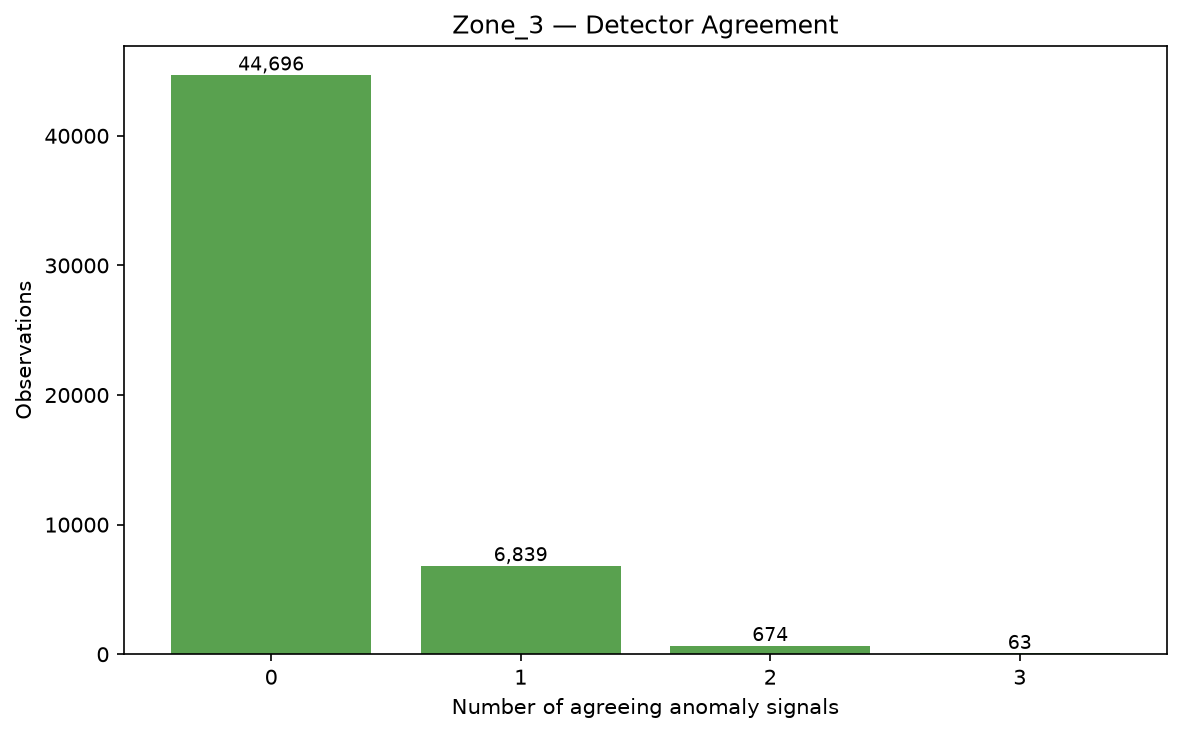

In [10]:
from IPython.display import Image, display

for zone in TARGETS:
    display(
        Image(
            filename=str(
                FIGURES_DIR
                / f"detector_agreement_{zone.lower()}.png"
            )
        )
    )

## 6. Hand-off contract

`outputs/anomalies_<zone>.csv` / `anomalies_all_zones.csv` — one row per timestamp per zone:

| Column | Meaning |
|---|---|
| `DateTime`, `Zone`, `Value_Watts` | Identity + the (possibly capped) consumption value |
| `Isolation_Forest_Score` / `_Flag` | Multivariate anomaly signal |
| `Zscore_1h` / `Zscore_24h` / `Statistical_Flag` | Rolling mean/std deviation |
| `MAD_Zscore` / `MAD_Flag` | Robust median/MAD deviation (highest precision of the three) |
| `Deviation_vs_Yesterday_Watts` | Value minus same time yesterday |
| `Signals_Agreeing` | 0–3, how many of the three detectors fired |
| `Severity_Level` | **Normal / Warning / Critical** — use this to prioritize review |
| `Is_Anomaly` | Any detector fired (recall-oriented; filter `Severity_Level == "Critical"` for a stricter list) |
| `Raw_Value_Watts` / `Capped_By_Preprocessing` / `Suppressed_Amount_Watts` | Whether preprocessing's IQR capping altered this row, and by how much |
| `Eligible_For_Scoring` | False for the first 24h (not enough history yet) |